This Project uses the diabetes_130_us_hospitals_combined dataset from ucimlrepo
We are maintaining the virutal environement with pixi

This project is being used for analyis in Multi-layer Perceptron Capstone Project at Humber Polytechnic - Clinical Bioinformatics Project

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import MLP as mlp
import testing as test




In [2]:
#load the dataset

diabetes_data = pd.read_csv("../data/diabetes_health_indicators.csv")

   HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  HeartDiseaseorAttack  \
0       1         1          1   40       1       0                     0   
1       0         0          0   25       1       0                     0   
2       1         1          1   28       0       0                     0   
3       1         0          1   27       0       0                     0   
4       1         1          1   24       0       0                     0   

   PhysActivity  Fruits  Veggies  ...  NoDocbcCost  GenHlth  MentHlth  \
0             0       0        1  ...            0        5        18   
1             1       0        0  ...            1        3         0   
2             0       1        0  ...            1        5        30   
3             1       1        1  ...            0        2         0   
4             1       1        1  ...            0        2         3   

   PhysHlth  DiffWalk  Sex  Age  Education  Income  Diabetes_binary  
0        15         1    0  

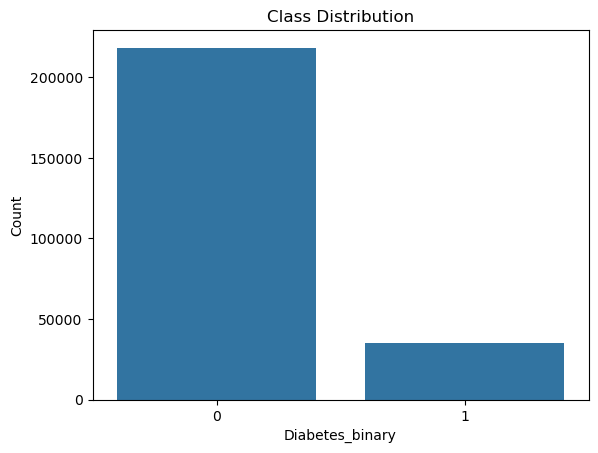

Figure saved to: ../figures/data_balance.png


<Figure size 640x480 with 0 Axes>

In [3]:
# Explore the dataset

print(diabetes_data.head())
print(diabetes_data.info())
print(diabetes_data.isnull().sum())

# Define save_figure function
def save_figure(figure, filename):
    """Save a matplotlib figure to a file"""
    import os
    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    # If figure is provided, use it; otherwise use current figure
    if figure is not None:
        figure.savefig(filename, dpi=300, bbox_inches='tight')
    else:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {filename}")

# Check data balance and save figure
data_balance = mlp.check_balance_data(diabetes_data)
save_figure(plt.gcf(), "../figures/data_balance.png")



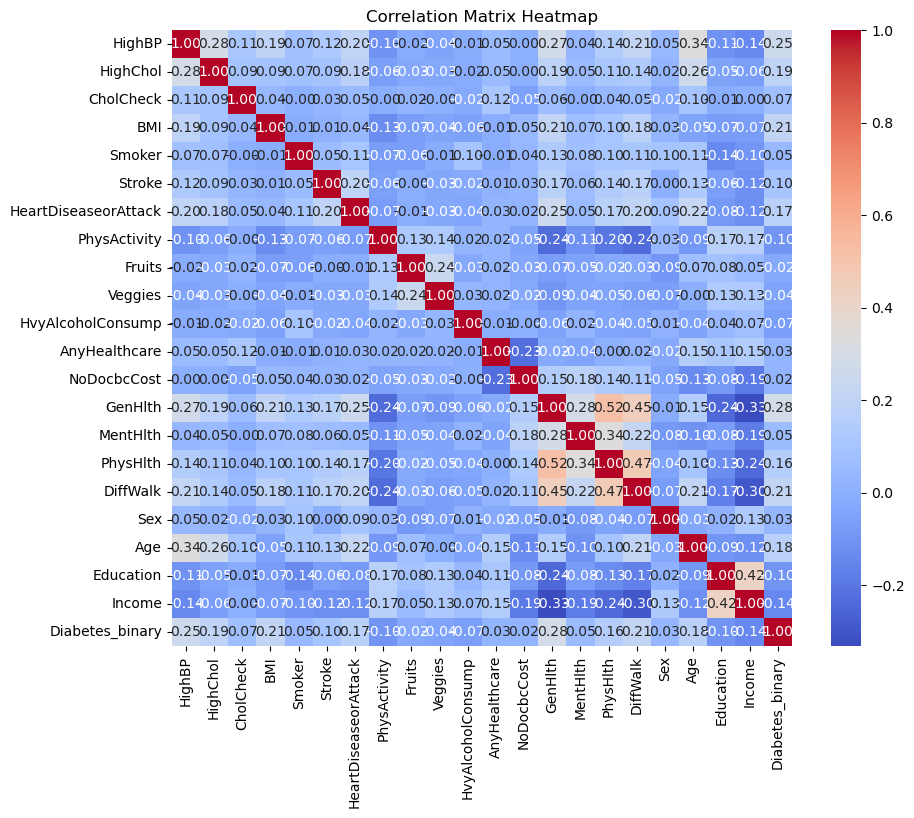

Data preprocessing completed!
Original data shape: (253680, 22)
Clean data shape: (388754, 16)
Selected columns: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income', 'Diabetes_binary']


In [4]:
# Reload the MLP module to get the updated function
import importlib
importlib.reload(mlp)

#cleaning and preprocessing the data 
data = diabetes_data.copy()

clean_data = mlp.clean_data(data)
corr_matrix= mlp.cor_matrix(clean_data)
clean_data = mlp.scale_features(clean_data)
clean_data = mlp.select_features(clean_data)
clean_data = test.fix_oversampling(clean_data)

print("Data preprocessing completed!")
print(f"Original data shape: {data.shape}")
print(f"Clean data shape: {clean_data.shape}")
print(f"Selected columns: {list(clean_data.columns)}")


In [5]:

# Train the MLP model for top 15 features selected using Anova F-test from SelectKBest
trained_model = mlp.train_mlp(clean_data)

              precision    recall  f1-score   support

           0       0.78      0.69      0.73     38918
           1       0.72      0.80      0.76     38833

    accuracy                           0.75     77751
   macro avg       0.75      0.75      0.75     77751
weighted avg       0.75      0.75      0.75     77751

[[26980 11938]
 [ 7788 31045]]


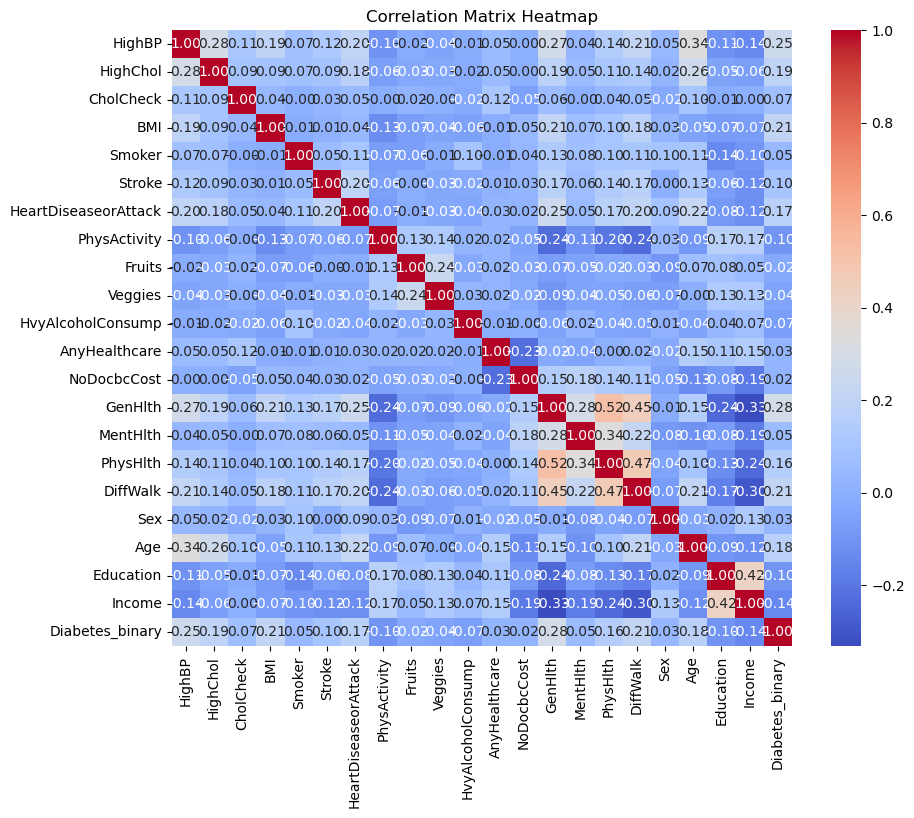

In [6]:
#train the model with out selected features


clean_data2 = mlp.clean_data(data)
corr_matrix= mlp.cor_matrix(clean_data2)
clean_data2 = mlp.scale_features(clean_data2)
clean_data2 = mlp.select_features(clean_data2)
clean_data2 = test.fix_oversampling(clean_data2)



In [7]:
trained2_model= mlp.train_mlp(clean_data2)

              precision    recall  f1-score   support

           0       0.78      0.69      0.73     38918
           1       0.72      0.80      0.76     38833

    accuracy                           0.75     77751
   macro avg       0.75      0.75      0.75     77751
weighted avg       0.75      0.75      0.75     77751

[[26980 11938]
 [ 7788 31045]]


In [8]:
### Retrain the model with more layers and neurons

trained3_model = mlp.train_mlp(clean_data, hidden_layers=(128, 64, 32), max_iter=200)

### Visualize the results with AUROC and PR curves for the retrained model


              precision    recall  f1-score   support

           0       0.78      0.72      0.75     38918
           1       0.74      0.79      0.77     38833

    accuracy                           0.76     77751
   macro avg       0.76      0.76      0.76     77751
weighted avg       0.76      0.76      0.76     77751

[[27986 10932]
 [ 8005 30828]]


Figure saved to: ../figures/model_1_results.png


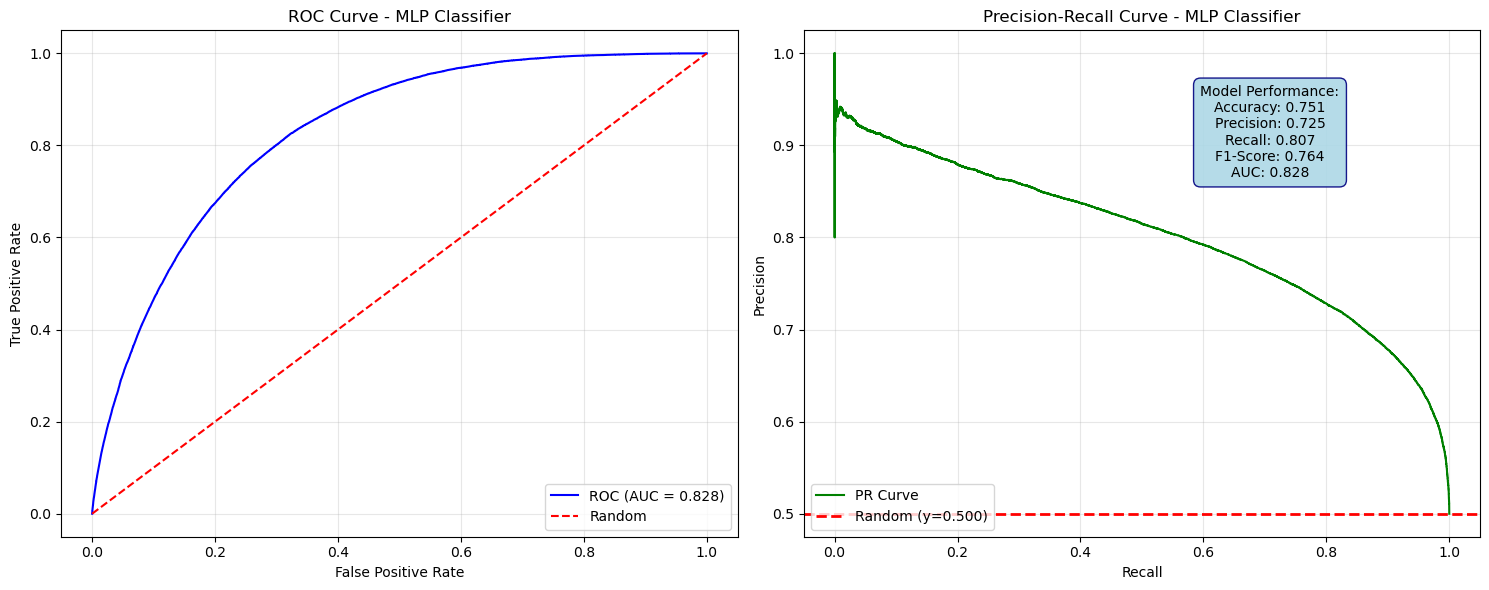

Figure saved to: ../figures/model_2_results.png


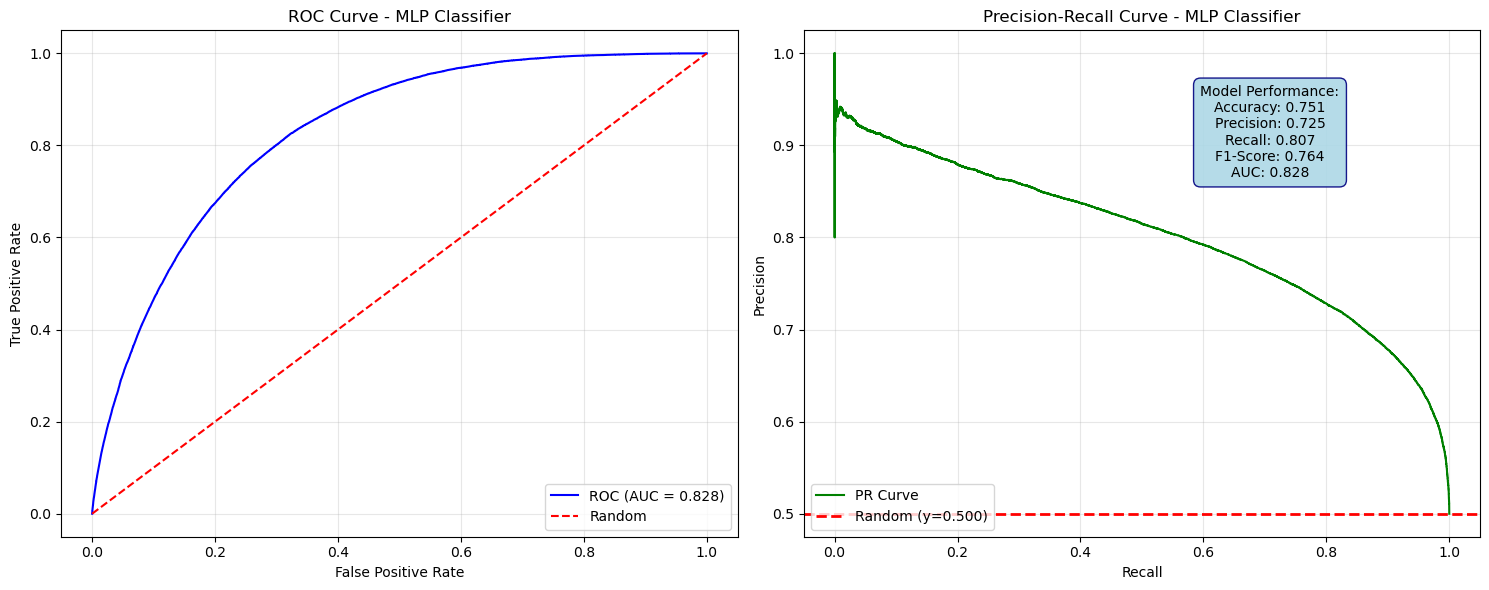

Figure saved to: ../figures/model_3_results.png


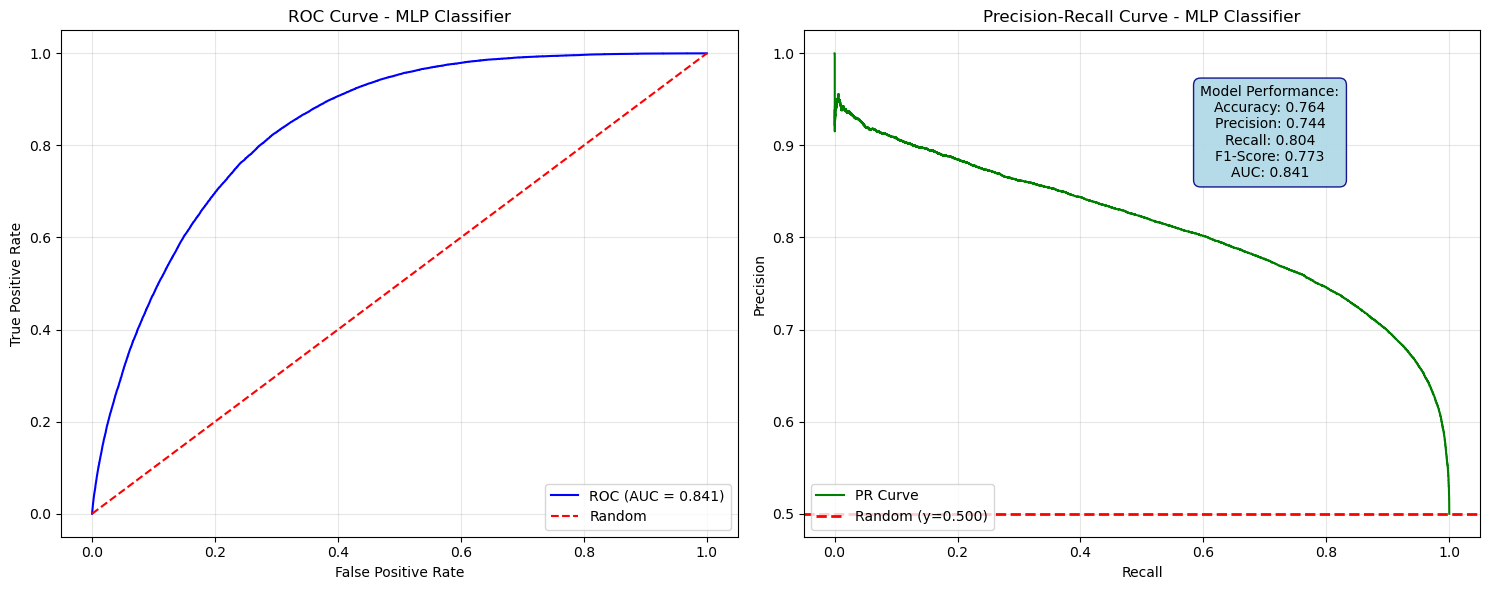

In [18]:
### Visualize the results with AUROC and PR curves
#import mlp again to ensure the latest version is used
import importlib
import MLP as mlp
importlib.reload(mlp)


model_1_fig = mlp.visualize_results(trained_model, clean_data)
save_figure(model_1_fig, "../figures/model_1_results.png")
plt.show()  # Display the figure
plt.close()  # Close to free memory

model_2_fig = mlp.visualize_results(trained2_model, clean_data2)
save_figure(model_2_fig, "../figures/model_2_results.png")
plt.show()  # Display the figure
plt.close()  # Close to free memory

model_3_fig = mlp.visualize_results(trained3_model, clean_data)
save_figure(model_3_fig, "../figures/model_3_results.png")
plt.show()  # Display the figure
plt.close()  # Close to free memory



